# Tufa Labs ARC3 submission

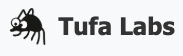

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["thtennant/taaf-kaggle-source-share-fork", "driessmit1/arc3-vllm-h100-wheelhouse-v3"]
# --- v21: Qwen3.8-27B-FP8 model pin ------------------------------------------
# The one axis this project has never varied. Everything else in this notebook
# is byte-identical to v20; see scripts/build_v21_notebook.py.
QWEN_MODEL_OWNER = "foysalemonshanto"
QWEN_MODEL_SLUG = "qwen3-8-27b-fp8-repacked-v1"
QWEN_MODEL_REF = f"{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}"
QWEN_MODEL_FRAMEWORK = "pytorch"
QWEN_MODEL_VARIATION = "hf-fp8"
QWEN_MODEL_VERSION = "1"
QWEN_SERVED_MODEL_NAME = "Qwen/Qwen3.8-27B-FP8"

# Keep the whole run offline: the weights are mounted, nothing may be fetched.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


# A Kaggle *Model* does not mount where a Kaggle *dataset* does. The documented
# layout is /kaggle/input/models/<owner>/<slug>/<framework>/<variation>/<version>,
# but the framework segment's case has been seen both ways and some images drop
# the "models" prefix, so probe every shape rather than hard-coding one and
# discovering the mistake 12h into a GPU run.
def _model_mount_candidates() -> list:
    roots = [Path("/kaggle/input/models") / QWEN_MODEL_OWNER / QWEN_MODEL_SLUG,
             Path("/kaggle/input/models") / QWEN_MODEL_SLUG,
             Path("/kaggle/input") / QWEN_MODEL_SLUG]
    frameworks = [QWEN_MODEL_FRAMEWORK, QWEN_MODEL_FRAMEWORK.capitalize(), "PyTorch"]
    seen, out = set(), []
    for root in roots:
        for framework in frameworks:
            candidate = root / framework / QWEN_MODEL_VARIATION / QWEN_MODEL_VERSION
            if str(candidate) not in seen:
                seen.add(str(candidate))
                out.append(candidate)
    return out


_qwen_candidates = _model_mount_candidates()
QWEN_MODEL_PATH = next((c for c in _qwen_candidates if c.is_dir()), None)
if QWEN_MODEL_PATH is None:
    raise FileNotFoundError(
        "Qwen3.8 Kaggle Model is not attached. Tried:\n  "
        + "\n  ".join(str(c) for c in _qwen_candidates)
        + "\nAttach: Qwen3.8 27B FP8 Repacked -> PyTorch -> hf-fp8 -> Version 1"
    )

# Fail before the wheelhouse install rather than inside vLLM: a half-mounted
# checkpoint costs a whole GPU session to discover otherwise.
_qwen_required = [
    "config.json",
    "model.safetensors.index.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "chat_template.jinja",
]
_qwen_missing = [n for n in _qwen_required if not (QWEN_MODEL_PATH / n).is_file()]
if _qwen_missing:
    raise FileNotFoundError(
        f"Qwen3.8 mount {QWEN_MODEL_PATH} is incomplete; missing: " + ", ".join(_qwen_missing)
    )
_qwen_shards = sorted(QWEN_MODEL_PATH.glob("*.safetensors"))
if len(_qwen_shards) != 18:
    raise RuntimeError(
        f"Unexpected Qwen3.8 checkpoint layout: {len(_qwen_shards)} safetensors files, expected 18."
    )
print(f"taaf.kaggle: qwen3.8 model = {QWEN_MODEL_PATH} ({len(_qwen_shards)} shards)")
# -----------------------------------------------------------------------------
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# The bundled setup resolves weights by owner/slug through THIS map first, so
# mapping the model ref to its mounted directory is the whole path fix.
kaggle_input_paths[QWEN_MODEL_REF] = str(QWEN_MODEL_PATH)

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
    "TAAF_QWEN_MODEL_PATH": str(QWEN_MODEL_PATH),
    "TAAF_QWEN_SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    "HF_HUB_OFFLINE": "1",
    "TRANSFORMERS_OFFLINE": "1",
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# --- v21: rewrite the bundled setup's model identity --------------------------
# The bundle ships ONE setup command: a here-doc Python script that starts vLLM.
# Rather than fork it (and inherit the job of keeping a 10KB copy in step), we
# rewrite exactly the three top-level string assignments that name the model,
# and raise if any of them is missing -- a bundle that has drifted must fail
# loudly, never serve the old model under the new label.
import re as _re


def _replace_python_assignment(command: str, variable_name: str, value: str):
    pattern = rf"(?m)^{_re.escape(variable_name)}\s*=\s*(['\"])[^\r\n]*?\1\s*$"
    return _re.subn(pattern, f"{variable_name} = {value!r}", command, count=1)


def _patch_qwen38_setup_commands(commands: list) -> list:
    replacements = {
        "MODEL_OWNER": QWEN_MODEL_OWNER,
        "MODEL_SLUG": QWEN_MODEL_SLUG,
        "SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    }
    counts = {name: 0 for name in replacements}
    env_patches = 0
    patched = []
    for raw in commands:
        command = str(raw)
        for name, value in replacements.items():
            command, n = _replace_python_assignment(command, name, value)
            counts[name] += n
        # Make the offline pins explicit in the vLLM child process too.
        if "def vllm_env()" in command and "'VLLM_NO_USAGE_STATS': '1'," in command:
            command = command.replace(
                "'VLLM_NO_USAGE_STATS': '1',",
                "'VLLM_NO_USAGE_STATS': '1',\n"
                "            'HF_HUB_OFFLINE': '1',\n"
                "            'TRANSFORMERS_OFFLINE': '1',",
                1,
            )
            env_patches += 1
        patched.append(command)
    missing = [name for name, n in counts.items() if n == 0]
    if missing:
        raise RuntimeError(
            "Could not repoint the bundled setup at Qwen3.8; missing assignment(s): "
            + ", ".join(missing)
            + ". The attached source bundle's setup_commands.json has changed."
        )
    print(f"taaf.kaggle: qwen3.8 setup patch = {counts}, vllm_env offline patches = {env_patches}")
    return patched
# -----------------------------------------------------------------------------

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
_setup_commands = _patch_qwen38_setup_commands(json.loads((BUNDLE_DIR / "setup_commands.json").read_text()))
for command in _setup_commands:
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

# The gate that stops a silently-failed patch shipping a Qwen3.6 run labelled
# Qwen3.8: the bundled setup exports the served id it actually started.
_served = os.environ.get("INFERENCE_ANALYZER_MODEL", "")
if _served != QWEN_SERVED_MODEL_NAME:
    raise RuntimeError(
        f"setup completed but the analyzer model id is {_served!r}, expected {QWEN_SERVED_MODEL_NAME!r}"
    )
print(f"TAAF_MODEL_PIN SERVED_MODEL_NAME={_served} MODEL_PATH={QWEN_MODEL_PATH}")


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

# Composite graft install (bench = the v28 stack, split into two arms): the single cell-12
# entry point shipped in our
# goalkeep stops the agent's carried world model being wiped on every game over /
# level change (measured: the stock harness carried a non-empty model on only
# 33 of 481 turns) and injects a compact digest of MEASURED outcomes -- per-action
# board-change rates, level completions, game-over cadence -- every turn.
# hudmask segments the status/timer band out of that change signal. board_changed
# is a whole-frame diff, so on 10 of the 25 public games it is true 100% of the
# time and the rate table carries zero bits (tn36's live v18 prompt read
# 'MOUSE 61/61'). The band is discovered from play alone by action-independence
# -- a row/column every base action drives at >=90% is a HUD, one that any action
# leaves alone is gameplay -- learned once and reused for every later level of the
# game, with earlier evidence re-scored retroactively once the band is found.
# Measured offline on all 25 public games: informative action tables 15 -> 23,
# and the 17 games where no band exists are bit-identical.
# clickmap breaks the single MOUSE bucket down by WHAT WAS UNDER THE CURSOR.
# goalkeep has to aggregate by base action -- a click carries coordinates, so keying
# on the display string gives one bucket per pixel -- which means the entire measured
# world model of a 4096-way action space is one number (the live v19 run told the
# agent 'MOUSE 72/100'). clickmap keys the change ledger on two game-agnostic
# properties of the clicked cell in the before-frame: its colour, and the size of the
# contiguous same-colour block it belongs to, backing off from the conjunction to
# either marginal. Measured prequentially on the real recorded v19 commit run (291
# clicks): Brier 0.1414 -> 0.0627 against goalkeep's single rate, and 21 'this kind
# of click has never done anything' claims at 0.952 precision. On a uniform-random
# control over all 19 public games that accept clicks (5700 clicks) it is better on
# 16 of 19 and never worse by more than 0.007. It also reports its own falsifications:
# when a kind of click that had been inert for >=5 tries suddenly works, the digest
# says so with the count and the action number, rather than quietly updating a rate.
# searchmap reports the STRUCTURE of the action space, which is the thing the agent
# needs in order to work out what it is even optimising. The reward channel cannot
# tell it: the harness builds reward as (levels_completed - previous)/number_of_levels,
# i.e. level_completed rescaled, and on the real v21 commit run that fired ONCE in
# 375 actions -- three of the four games never saw a positive reward at all. So the
# agent falls back on the per-action change rate, which on click games is saturated
# (real tn36: 'MOUSE 144/150', ~0.24 bits).
# What that boolean hides, measured on the real run: tn36 changes exactly 3 cells on
# every one of 150 actions, 99% co-located with the click, from only 16 distinct
# targets -- 15 of which have only ever shown TWO local patterns. It is not a
# 4096-cell click space; it is sixteen binary switches hammered nine times each,
# with 37% of actions returning the play area to a configuration already visited.
# searchmap reports coverage and revisits (both pure counting over what happened),
# and -- gated -- the switch reading, which reframes the level as a COMBINATION
# rather than a sequence. That last one is an inference, so it was put through the
# same prequential test that RETIRED the deadend graft at 0.486: label from the past
# only, score every later visit against a future the label could not see. It scores
# 0.974/0.980/0.977/0.969 at support >=2/3/4/6 -- holding up as evidence accumulates,
# where deadend degraded -- and every residual error was a lone two-pattern site on a
# game that is not a switch puzzle. Gated on a quorum of 3 agreeing sites it is
# 113/113, precision 1.0000, firing on tn36 only, available from action 27 of 150.
# Nothing is game-specific: it reads action targets and cell diffs.
# clockwatch tells the agent about the budget that actually kills it. Measured over
# three archived commit runs -- 12 game-runs, 665 analyze() calls, by
# experiments/probe_budget.py: every archived game ends on the 7920 s per-game
# wall-clock and NONE on the action cap; the model generates at a flat ~30.7 tok/s so
# that wall-clock is really a fixed ~240k generated-token budget (the three arms agree
# to within 3% on total reasoning characters); 97.6-98.3% of every generated token is
# reasoning; and 12 of 12 games ended INSIDE an analysis step that never produced an
# action, stranding 67k-171k reasoning characters per arm mid-thought.
# The agent is told none of this. 'time_remaining_seconds' appears 7-9 times per arm
# in ~70,000 lines of transcript, only ever inside the raw dict returned by action(),
# never in prompt text -- in a 132-minute game it typically sees the clock once, at
# action 1. What the prompt DOES budget is actions: the stock system prompt says 'Do
# not ration tool calls when the state is unclear', and the efficiency graft adds the
# (baseline/yours)^2 note every turn. But the score is min(raw, cap) with cap =
# 100*sum(i completed)/sum(i all), and on every game this project has scored the CAP
# bound, not the efficiency term -- tn36 cleared level 1 in 24 actions against a
# baseline of 32, saturating the efficiency term at 115, and still scored the cap's
# 3.57. So the agent economises the resource that barely pays and is told explicitly
# not to ration the one it dies of.
# clockwatch REPORTS and does not cap, truncate or suppress anything, which is the
# direct lesson of 2026-08-18 and 2026-08-22 (twice, "waste" was measured and twice it
# turned out to be the exploration that scored). Checked again here: the games that
# SCORED have the HIGHEST concentration of clock in one long analysis step. Long
# thinking is not the disease; long thinking with no idea what it costs, ending in a
# plan the clock never let the agent play, is. Every number injected is read from the
# harness -- the clock is anchored on action results and extrapolated with
# time.monotonic() between them, turn cost is the observed mean on this game -- and
# with no anchor, or no per-game runtime limit, it renders nothing at all.
# lawbook reports what each action has actually DONE to the objects on the board, and
# says so when a regularity that had held several uses in a row breaks. The stock
# prompt demands a revised world model every turn and hands back the previous turn's
# version, but nothing in the harness ever checks that model against the board -- so a
# law the agent induced on turn 4 stays in the carried world model long after the game
# stopped obeying it.
# Three progressively less naive world models were scored prequentially on 8 real
# commit-run game-passes (647 actions under the real 27B, not a random policy) by
# experiments/probe_worldmodel.py, probe_lawstability.py and probe_objectlaw.py:
# (1) BOARD-KEYED PREDICTION IS DEAD. A (board, action) key recurs on only 2.6% of
#     actions and, when it recurs, the environment agrees with itself 47% of the time.
#     That reproduces deadend's 0.486 on independent data and retires schema_lite's
#     MemoWorldModel, whose 99.47% precision came from a random policy.
# (2) GLOBAL EFFECT SIGNATURES ARE DEAD. Changed-cell count, palette swaps, bounding
#     box and whole-board translation all predict at or below the base rate; the
#     whole-board translation search never fires once in 647 actions.
# (3) OBJECT-LEVEL EFFECTS ARE NOT. The law the agent itself wrote on the real m0r0 run
#     -- "LEFT moved the two cyan squares apart by 5 cells each" -- cannot be expressed
#     globally: one object went left, the other right, the board did not move. Scored
#     per object and gated on a run of consecutive agreeing uses: run>=3 gives 25.8%
#     coverage at 87.4% precision, run>=5 gives 18.2% at 92.4%. It self-selects by
#     game, firing on 102 of 148 m0r0 actions at 95.1% while nearly silencing itself on
#     the tn36 click game, where object laws are false.
# lawbook PREDICTS NOTHING -- that is deadend's exact failure mode. Every line is a
# retrospective statement about actions already taken ("RIGHT: on each of its last 7
# uses, 2 objects moved 4 columns apart"), true by construction. The measured 92.4% is
# not a claim made to the agent; it is why a BREAK is worth a line: once a law has held
# five times it holds again ~92% of the time, so a break is a one-in-twelve event and
# the one moment the world model should be revised. Breaks go stale after 10 actions --
# on the real m0r0 replay, without that a surprise from action 12 was still being
# repeated on all 136 turns after it, and tn36 emitted a line on 95 of its 102 turns.
# It caps nothing, suppresses no action, spends no LLM turn and no environment action,
# and costs 3.8 ms per action measured on the archived frames.
# winframe transcribes the board each level was actually WON on -- the one frame in the
# whole game that says what the objective is, and the one frame nothing in the harness
# reads. GameState.frame returns raw.frame[-1] ("the final visible frame"). On an
# ordinary step raw.frame holds one layer and that is the board. On a level-COMPLETING
# step it holds two: layer 0 is the terminal board of the level just cleared, layer 1 is
# the opening board of the next one. .ascii, .segmentation and every graft above read
# the last layer, so at the moment the agent is scored it is handed the NEXT level's
# board and told it is the current one.
# Measured on the archive, 2026-08-25 (experiments/probe_winframe.py, replay_winframe.py):
# (1) THE ONE-LEVEL WALL IS NOT A BUDGET WALL. Every point this project has scored came
#     from clearing exactly one level and no arm has ever cleared two, which was assumed
#     to be a clock problem. On the two archived passes that cleared a level the agent
#     won and then kept playing: 33 more actions on one, 119 on the other. 119 is four
#     times what solving level 1 had taken. The room is there; the goal is not.
# (2) IT SPENDS THAT ROOM ON THE WRONG GOAL. Verbatim from the v23_v1 m0r0 transcript
#     after the win: "Level 1's board: I don't have it anymore, but from memory ... the
#     win was after UP, MOUSE, RIGHT, RIGHT -> (10,22)/(10,38)" and then "so the winning
#     position was (10,22,10,38)?? That's a weird position." It is a weird position
#     because it is not the winning position -- it is where the squares sit at the START
#     of level 2, read off layer 1. Layer 0 says level 1 ended on a SINGLE object,
#     colour 10, 25 cells, rows 9-13, cols 29-33: the two squares had converged into the
#     gap between them. Both archived passes end level 1 on that identical configuration
#     by different routes, so it is a fact about the game, not one trajectory.
# (3) THE BAD FRAME COMPOUNDS INTO A BAD LAW. The agent went on to induce "the generator
#     sets the next level's start = previous level's goal position" -- false, and false
#     for the same reason: it had compared level 2's opening board against itself. Off
#     layer 0 the winning board and the next level's start share no object at all.
# winframe PREDICTS NOTHING and generalises nothing -- deadend's failure mode was making
# a prediction, being right 48.6% of the time, and getting worse as evidence accumulated.
# Every line is a transcription of frames the environment has already returned: the board
# one action before the win, the board the win was scored on, the opening board of the
# level that followed, which objects changed between the first two, and which the last
# two share. There is no model here to be wrong. It fires only once a level has been won,
# so on a game that never scores it is silent for the whole run -- the same self-gating
# as searchmap's quorum and lawbook's run gate, but earned for free rather than tuned.
# It caps nothing, suppresses no action, and spends no LLM turn and no environment action.
# carryover says what survives a level boundary. winframe recovers the board a level was
# WON on; this answers the next question, which the agent had been getting wrong: of
# everything it worked out on that level, what is still true on the one it is now
# playing? Its own answer, induced after clearing m0r0 level 1, was "the generator sets
# the next level's start = previous level's goal position" -- false, and false because
# it had compared level 2's opening board against level 2's opening board.
# Measured 2026-08-26 (experiments/probe_levelcarry.py). The 25 public games ship as
# importable source and their game objects expose set_level(index), so every level of
# every public game can be OPENED without being played. Over all 25 games and all 158
# consecutive level pairs:
#     base actions with the same effect on the next level    587/631  = 93.0%
#     level openings that repeat the previous opening          0/158  =  0.0%
#     objects carried unchanged into the next opening       1084/5068 = 21.4%
#     (colour,size) shapes shared between openings          1258/3226 = 39.0%
# THE CONTROLS CARRY; THE LAYOUT DOES NOT. The two archived game-passes that ever
# crossed a boundary under the real 27B agree independently: every base action with
# support on both sides kept its board-changing rate (5/5), while the openings shared
# 1 of 5 shapes.
# A rate over 25 games is a prior, not a fact about the game being played, so the graft
# never states it alone -- it prints THIS game's own counts beside it, per action either
# side of the boundary and per object between the two openings, so a game that breaks
# the rule says so in the same breath. Both halves are transcriptions of actions already
# taken and frames already returned; it PREDICTS NOTHING, which is deadend's failure
# mode. Change is judged on the hudmask-masked play area, because unmasked, tn36's
# status band advances on every action and every control reads as carrying everywhere.
# It is silent until the environment has scored a level -- there is no carry to describe
# until there are two levels to compare -- and silent about controls until this game has
# used one at least 3 times either side. Measured over the archive: 5 boundaries, 157
# speaking turns of 2004, 2.3 ms/turn against a ~300 s turn. It caps nothing, suppresses
# no action, and spends no LLM turn and no environment action.
# undo states the cost of the level in progress and the one way out of it. This package
# has refuted dead-end detection three times -- sterile tail 1.0% (2026-08-18), 0.3%
# (2026-08-22), and on 2026-08-27 the novelty curves of the passes that scored and the
# passes that never scored came out indistinguishable (Q4 0.78 vs 0.75, longest run
# without a new board 2.8 vs 3.0). The agent does not get stuck, deadend stays unwired,
# and this graft does not resurrect it.
# What all three measurements share is that they read the AGENT and inferred the
# environment from it, which cannot see a trap the agent never walked into. Driving the
# 25 public games directly through set_level (experiments/probe_reversible.py) says what
# none of them could:
#     states with no way back to the level opening   2210/2454 = 90.1%
#     RESET restored the level opening exactly        306/306  =  100%
# The environment is almost entirely one-way AND it ships a perfect undo, and the two
# halves explain each other: there are no dead ends because RESET exists, not because
# the moves are gentle. The live 27B confirms the first half independently -- over 28
# archived game-passes only 31 of 1310 board-changing moves ever walked one back, 2.4%.
# The agent has been told neither half. "RESET" appears nowhere in the prompt text; the
# model meets it as a bare token in valid_actions. Across the whole archive it has been
# chosen deliberately 3 times in ~1980 actions, and the transcript of one of those shows
# the model spending reasoning on what the button even is: "does RESET restore the ticks
# to initial? After the RESET at action 62, what was the tick state?"
# The block prints the actions spent on the current level, how one-way THIS game has
# been on the agent's own trace, and the harness fact with its measurement beside it so
# a freely-reversible game contradicts the prior in the same breath. It PREDICTS
# NOTHING, never says the agent is stuck, never proposes RESET and never suppresses an
# action -- deadend made a call and scored 0.486. Change is judged on the hudmask-masked
# play area, because unmasked, tn36's status band means no board ever repeats and the
# line is a tautology. It is gated to cost milestones that double from 24 actions:
# ungated it spoke on 64% of turns and said the same paragraph every time, which is the
# failure lawbook was caught on. Measured over the archive: 431 speaking turns of 2205,
# 0.7 ms/turn against a ~300 s turn. It is also the first graft here that speaks on a
# game that never scores -- winframe and carryover are both structurally silent until a
# level is scored, and 19 of the 24 archived game-passes never score.
# untried names the controls the game declared and the agent never once pressed. Every
# turn the harness puts valid_actions in front of the model, and goalkeep follows it with
# a change-rate table keyed on the actions actually EXECUTED -- so an action never tried
# does not appear as untested, it is simply absent, and the table reads as a complete
# account of the controls. It is not one. Over the 32 archived game-passes only 41% ever
# pressed every declared action, and 8 of those 13 are tn36, which declares exactly one:
# of the 24 passes on a game with more than one control, 5 covered the declared set.
# Driving the 25 public games through set_level (experiments/probe_actionprofile.py, 150
# level openings, 600 action-level pairs) says what that costs:
#     declared action list identical on every level    25/25 games
#     declared actions that move the board somewhere   545/600 = 91%
#     ... found by ONE press at the level opening      411/600 = 69%
#     permanently dead on all six levels               3/25 games
# and on the two archived games it is checkable on, the specific miss: sk48's ACTION7
# moves the board on 40/40 presses at every one of six levels and was pressed ZERO times
# in 12 archived passes, while ACTION6 -- dead 0/40 at every level -- was pressed in 10
# of them. m0r0's ACTION6 is live and four of eight passes never pressed it. The agent is
# not overspending on exploration; it is underspending, on the one axis where a probe
# costs exactly one action and the declared list says in advance that the control exists.
# The second line bounds a claim goalkeep already makes. goalkeep emits "Never changed the
# board in N tries: ACTION3. Treat as inert unless state changed." The same 600-pair sweep
# says how far that reading travels: an action that moved the board on one level still
# moved it on a later level 431/445 = 97% of the time, but an action that moved NOTHING
# was still inert later only 30/55 = 55% -- and 55% is an UPPER bound, since "dead" is the
# absence of a detection by a finite walk and a longer walk can only turn dead into live
# (re-run at 240 steps, identical counts). Liveness transfers across a level boundary;
# inertness is a coin flip. So when a boundary is crossed and an action goalkeep called
# inert has not been re-tried, this says so.
# It never suppresses an action, never orders one and never claims an untried action will
# work -- the 2026-08-22 result stands, that a suppressor keyed on predicted inertness
# would have fired on the only sweep in the archive that cleared a fresh level. This graft
# points the other way: it reports a gap in coverage and states the cost of closing it,
# one action per control. Change is judged on the hudmask-masked play area for the same
# reason every other ledger here does. Gated on milestones that double from twice the
# declared action count, so a game is never nagged while the agent is still working
# through the list. Measured over the archive: 414 speaking turns of 2510 (16%), silent on
# 10 of 32 passes, 0.14 ms/turn against a ~300 s turn.
# forked source bundle (thtennant/taaf-kaggle-source-share-fork, src/taaf-grafts),
# importable here because the source-import cell above put every bundled repo on
# sys.path. install(bm, flags) wires the EfficiencyToolAgent analyzer (budget-aware
# per-turn note + net-zero waste detection, report-only) plus the RetryGuard
# analyzer chain layer (a proven pass-through rider) plus shortcircuit (no-op
# overshoot trimmer), printing the machine-parseable
# 'TAAF_GRAFTS FEATURES={...} API_VERSION=1' banner the commit-log gate reads.
# The run cell below reassigns bm.games (offline dup-game gate included) but never
# touches bm.solver, so swapping the solver instance here is safe: Benchmark.run
# deepcopies whatever solver is present at run time.
# install() is itself blanket-guarded (restores the original bm.solver on ANY
# error); the extra try/except-pass here is belt-and-suspenders so even an import
# failure of composite leaves bm.solver untouched (stock HarnessSolver).
# bench is a MEASUREMENT harness and this kernel is never submitted. Ten grafts have
# been built for this stack, every one argued from a real measurement of the
# environment, and not one has been shown to change the score -- because the only
# offline instrument available is a commit run of 4 game-passes, and two byte-identical
# runs of v22 scored 1.82 and 0.00 (2026-08-23). Every graft in the stack is
# INFORMATIONAL: none of them chooses an action, and their whole effect is the text
# goalkeep's digest puts in the prompt. So an arm can be turned off by suppressing that
# text and nothing else changes -- same code path, same wrappers, same engine calls.
# The run cell below plays four copies of ONE game concurrently, two tagged arm A and
# two arm B; bench reads the arm off each run's own artifact path and gives arm B the
# harness's own stock world-model methods back, which reproduces the v12 floor's prompt
# exactly. The result is a paired, within-run A/B on the outcome that decides the score.
# Arms: {"A": [], "B": ["*"]} -- A is the full v28 stack, B suppresses all of it. Name
# individual grafts instead of "*" to screen one graft at a time.
try:
    from taaf_grafts.composite import install

    install(bm, flags={"efficiency": True, "retry_guard": True, "shortcircuit": True, "goalkeep": True, "hudmask": True, "clickmap": True, "searchmap": True, "clockwatch": True, "lawbook": True, "winframe": True, "carryover": True, "undo": True, "untried": True, "bench": {"A": [], "B": ["*"]}})
except Exception as exc:  # noqa: BLE001 — any graft failure must fall back to stock
    print(f"[taaf_grafts] cell-12 graft failed, running stock: {type(exc).__name__}: {exc}")


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

# Bench game list: four tagged replicas of ONE game instead of three games plus a dup.
# Guarded on TRUE_SUBMISSION exactly as the dup gate it replaces, so it is provably
# inert in a real rerun, and it must live in this cell for the same reason: both
# branches above reassign bm.games. Each replica is the SAME env and the SAME
# ArcadeSpec with a distinct external_game_id (game_api.py:155), which is what
# satisfies Benchmark's unique-game_id check (benchmark.py:160) -- the identical
# mechanism the dup gate uses, verified at four copies by
# taaf_grafts/tests/run_bench_gate.py against the real offline engine.
# The tag is the whole channel: bench reads the arm letter out of each run's own
# artifact path, so the arm labels in benchmark.json cannot drift from the arms that
# were actually played. BENCH_GAME picks the env by prefix rather than by index
# because bm.games' order is the Arcade's, not ours.
BENCH_GAME = "sb26"
BENCH_TAGS = ("A0", "B0", "A1", "B1")
if not TRUE_SUBMISSION:
    try:
        from taaf_grafts.bench import make_replicas

        bm.games = make_replicas(bm.games, BENCH_GAME, BENCH_TAGS)
        print(f"[bench] game list: {[g.external_game_id for g in bm.games]}")
    except Exception as exc:  # noqa: BLE001 — any construction fault falls back to plain truncation
        print(f"[bench] replica build failed, using [:4]: {type(exc).__name__}: {exc}")
        bm.games = bm.games[:4]

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))
else:
    # Safety pack: a real rerun used to run with soft_end=None (no global soft
    # deadline; the wall budget was emergent). Cap at run start + 11h20m so the
    # solver drains and the shared scorecard closes before Kaggle's hard kill.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")